# **Esame del 15 gennaio 2026**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (10 punti + 1)**

Si consideri il seguente problema di Cauchy:

$$
\begin{cases}
y'(t) = -\pi y, \quad t_0<t\leq t_{\max}, \\
y(t_0) = 1,
\end{cases}
$$
dove $t_0=0$ e $t_{\max}=2$

#### **(1a) (1 punti) [T]** 

Verificare che $y(t) = \exp(-\pi t)$ è la soluzione esatta del problema.

##### **Soluzione.** 

Calcoliamo la derivata di $y$: $y^\prime(t) = - \pi exp(-\pi t)$ che sostituito nella prima equazione la soddisfa. Inoltre calcolando la soluzione in $t_0$ otteniamo il soddisfacimento anche della condizione iniziale.

#### **(1b) (3 punti) [T]** 

Illustrare il metodo di Eulero Esplicito per la soluzione numerica di equazioni differenziali ordinarie. Discutere la convergenza del metodo e la sua *assoluta* stabilità al variare del passo $h$.

##### **Soluzione.** 

Per poter risolvere numericamente il problema suddividiamo l'intervallo $I =
    [t_0, t_{\max}]$, con $t_0=0$ e $t_{\max}=2$, in $N$ sotto-intervalli con la stessa dimensione data da
$$
    h = \frac{t_{\max} - t_0}{N}
$$
e definiamo gli istanti discreti in cui calcoleremo la soluzione approssimata come $t_n
    = t_0 + nh$. Infine chiamiamo $u_n$ l'approssimazione di $y$ all'instante $t_n$,
ovvero vogliamo costruire $u_n \approx y(t_n)$.

Una possibilit\`a per discretizzare il problema di Cauchy presentato prima \`e
utilizzare una semplice approssimazione del tipo
$$
    \begin{cases}
        \dfrac{u_{n+1} - u_n}{h} = f(t_n, u_n) \\
        u_0 = \overline{y}_0
    \end{cases}
    \quad \Rightarrow \quad
    \begin{cases}
        u_{n+1} =  u_n + h f(t_n, u_n) \\
        u_0 = \overline{y}_0
    \end{cases}
$$
Quello che otteniamo \`e quindi una sequenza di valori $\{u_0, u_1, u_2, \ldots,
u_N\}$ che approssimano la reale soluzione $y$ negli istanti $\{t_0, t_1, t_2,
\ldots, t_N\}$. 

Eulero in avanti è
convergente al prim'ordine, inoltre Eulero in avanti risulta assolutamente stabile solo se
prendo $h$ sufficientemente piccolo, il metodo viene detto condizionatamente
assolutamente stabile e sotto la condizione
$$
    h < \frac{2}{|{\lambda}|}
$$
dove $\lambda$ e' il parametro associato al problema modello.

#### **(1c) (3 punti) [P]** 

Applicare il metodo di Eulero Esplicito utilizzando la function *eulero_avanti* fornita, scegliendo un passo temporale che garantisca l'assoluta stabilità del metodo. Rappresentare la soluzione numerica e la soluzione esatta.

In [1]:
import numpy as np
from functions import eulero_avanti

import matplotlib.pyplot as plt

##### **Soluzione.** 

Consideriamo il codice seguente

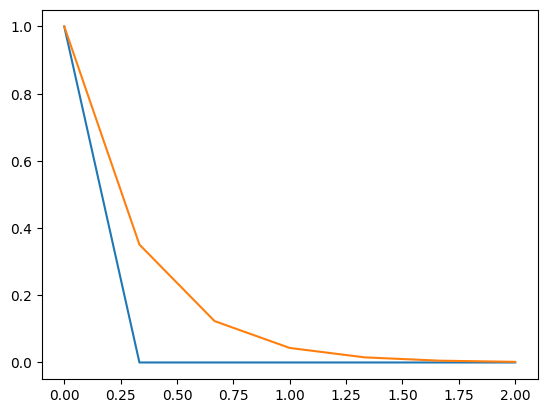

In [2]:
f = lambda t, y: -np.pi * y
y0 = 1
t0 = 0
t_max = 2

yex = lambda t: np.exp(-np.pi * t)

hlim = 2 / np.pi
h = 0.5 * hlim
tEA, yEA = eulero_avanti(f, t0, t_max, [y0], h)

plt.plot(tEA, yEA)
plt.plot(tEA, yex(tEA))

#### **(1d) (3 punti) [P]**  

Risolvere il problema per i seguenti valori di $h$: $h=[0.5, 0.1, 0.05, 0.01]$. Per ognuno calcolare l'errore massimo nell'intervallo $(0,2)$. Plottare l'errore in funzione di $h$ in scala logaritmica e verificare se i risultati teorici di convergenza sono confermati.

##### **Soluzione.**

Consideriamo il seguente codice

(5, 1)
(21, 1)
(41, 1)
(201, 1)


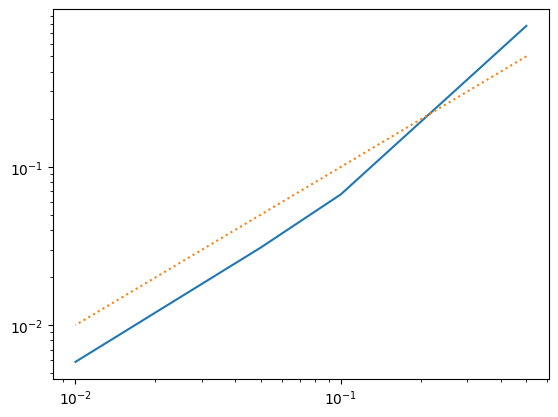

In [3]:
err = []
num = [0.5, 0.1, 0.05, 0.01]
for h in num:
    tEA, yEA = eulero_avanti(f, t0, t_max, [y0], h)
    print(yEA.shape)
    err.append(np.max(np.abs(yEA[:, 0] - yex(tEA))))

plt.loglog(num, err)
plt.loglog(num, num, ":")

L'andamento dell'errore è coerente con quanto ci si aspetta dalla teoria.

#### **(1e) (1 punto - extra) [T]**

Illustrare quali metodi possono essere utilizzati per ottenere un ordine di convergenza superiore a 1.

##### **Soluzione.** 

Crank-Nicolson ha ordine di convergenza pari a 2
$$
    \begin{cases}
        u_{n+1} =  u_n + \frac{h}{2} [f(t_{n}, u_{n}) +  f(t_{n+1}, u_{n+1}) ] \\
        u_0 = \overline{y}_0
    \end{cases}
$$
Alternativamente, possiamo considerare i metodi Runge-Kutta, che sono metodi di ordine superiore. Un esempio è il metodo di Runge-Kutta di ordine 4, che è definito come segue:
$$
    \begin{cases}
        k_1 = h f(t_n, u_n) \\
        k_2 = h f(t_n + \dfrac{h}{2}, u_n + \dfrac{k_1}{2}) \\
        k_3 = h f(t_n + \dfrac{h}{2}, u_n + \dfrac{k_2}{2}) \\
        k_4 = h f(t_n + h, u_n + k_3) \\
        u_{n+1} = u_n + \dfrac{1}{6} (k_1 + 2 k_2 + 2 k_3 + k_4)
    \end{cases}
$$
Il metodo di Runge-Kutta di ordine 4 è un metodo di ordine 4, cioè l'errore locale è $O(h^5)$ e l'errore globale è $O(h^4)$.

# **Esercizio 2 (10 punti)**

Si considerino i dati nel blocco di codice seguente che genera 20 coppie di dati e li salva nella variabile `data`.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import interp  # interpolazione lineare a tratti

np.random.seed(1)
N = 20
vals = np.linspace(0, 10, N)
noise = np.random.normal(0, 0.1, N)
# dati generati
data = vals * np.cos(vals) + noise

#### **(2a) (3 punti) [T]**

Presentare l'interpolazione Lagrangiana su nodi equispaziati, specificando proprietà e limitazioni. Proporre strategie migliorative.

##### **Soluzione.**

Date $n+1$ coppie di punti $(x_i, y_i)$ distinte, per $i=0, \ldots, n$, cerco un
polinomio di grado $n$ chiamato $\pi_n \in \mathbb{P}^n$, con $\mathbb{P}^n$
lo spazio dei polinomi fino al grado $n$, che passi per gli $n+1$ punti, ovvero,
tale che soddisfi
\begin{gather*}
    \pi_n(x_i) = y_i \quad i=0,\ldots,n.
\end{gather*}
Definisco quindi per ogni $i=0,\ldots,n$ un polinomio $\mathcal{L}_i$ di
grado $n$ con le seguenti caratteristiche:
\begin{gather*}
    \mathcal{L}_i(x_k) =
    \begin{cases}
        1 & \text{se } k=i\\
        0 & \text{se } k \neq i
    \end{cases}
    \quad \rightarrow \quad
    \mathcal{L}_i(x) = \prod_{j=0, j\neq i}^n \frac{x-x_j}{x_i-x_j}
\end{gather*}
tali polinomi sono detti polinomi caratteristici di Lagrange.

Date le proprietà dei polinomi di Lagrange, allora possiamo costruire
l'interpolante polinomiale $\pi_n(x)$ tale che $\pi_n(x_i) = y_i$ nel
seguente modo
\begin{gather*}
    \pi_n(x) = \sum_{i=0}^n y_i \mathcal{L}_i(x),
\end{gather*}
detto interpolante polinomiale Lagrangiano.

Nel caso di nodi equispaziati abbiamo la seguente stima di stabilità per l'errore
\begin{gather*}
    \Vert {\Pi_n f - \Pi_n \widetilde{f}}\Vert_\infty
    \leq \max_{i=0,\ldots,n} \vert{f(x_i) - \widetilde{f}(x_i)}\vert \max_{x\in I}
    \sum_{i=0}^n \vert{\mathcal{L}_i(x)}\vert
\end{gather*}
L'ultimo termine, che non dipende da $f$ ma solo dai valori dei $\mathcal{L}_i$ nei
nodi $x_i$, è detta costante di Lebesgue e, per nodi equispaziati,  è data da
\begin{gather*}
    \Lambda_n =  \max_{x\in I}\sum_{i=0}^n \vert{\mathcal{L}_i(x)}\vert \approx \frac{2^{n+1}}{e n
        (\log n+\gamma)}
\end{gather*}
tale costante diverge per $n \rightarrow \infty$ e quindi il metodo non risulta stabile, fenomeno di Runge. Una strategia per evitare questo problema è considerare i nodi di Chebychev-Gauss-Lobatto la cui costante di Lebesgue è data da
\begin{gather*}
    \Lambda_n < \frac{2}{\pi} \log n
\end{gather*}

#### **(2b) (3 punti) [P]**  

Calcolare l'interpolante polinomiale lagrangiano sfruttando le function di *numpy* *polyfit* e *polyval*. Rappresentare graficamente i dati insieme all'interpolante polinomiale Lagrangiano. Che fenomeno si osserva?

##### **Soluzione.**   

Il codice per riprodurre la soluzione è il seguente.

/tmp/ipykernel_247935/211772076.py:2: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(vals, data, deg=N - 1)


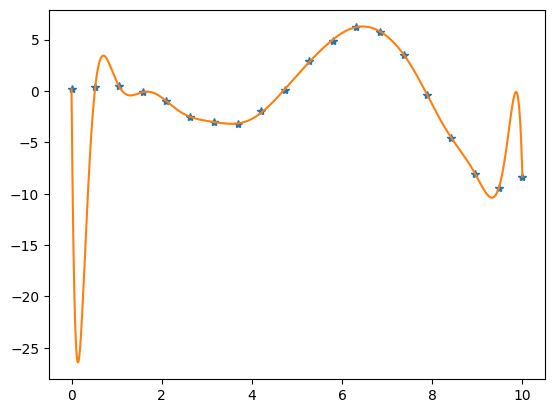

In [5]:
# costruzione dell'interpolante polinomiale
p = np.polyfit(vals, data, deg=N - 1)
p_I = lambda x: np.polyval(p, x)

# rappresentazione grafica dell'interpolante e dei dati
xx = np.linspace(0, 10, 1000)
plt.plot(vals, data, "*")
plt.plot(xx, p_I(xx))
plt.show()

Dato che i punti sono stati generati in maniera equispaziata notiamo che ai bordi l'interpolazione è poco accurata, che è appunto di fenomeno di Runge.

#### **(2c) (2 punti) [P]**  

Rappresentare graficamente i dati insieme all'interpolante lineare a tratti, calcolata usando la function *interp* di *numpy*. Che fenomeno si osserva?

##### **Soluzione.**

Il codice per riprodurre la soluzione è il seguente.

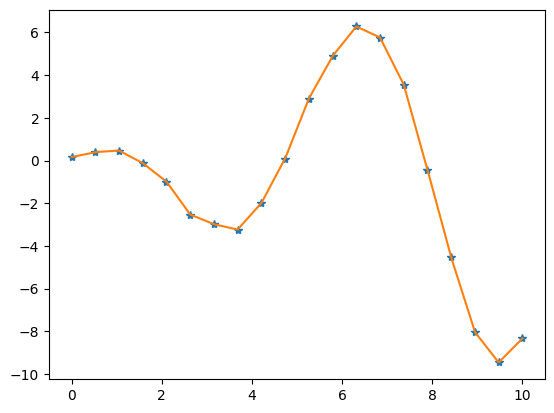

In [6]:
spline_lineare = lambda x: interp(x, vals, data)

# rappresentazione grafica dell'interpolante e dei dati
xx = np.linspace(0, 10, 1000)
plt.plot(vals, data, "*")
plt.plot(xx, spline_lineare(xx))
plt.show()

Essendo un'interpolazione lineare a tratti non notiamo più il fenomeno di Runge.

#### **(2d) (2 punti) [P]**

Rappresentare graficamente i dati insieme all'approssimante ai minimi quadrati di grado m = 10. Che fenomeno si osserva?

##### **Soluzione.**

Il codice per riprodurre la soluzione è il seguente.

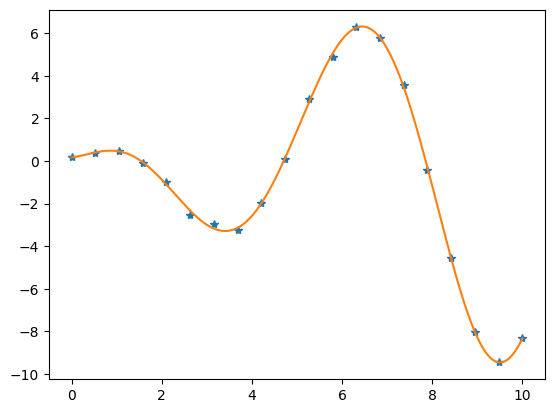

In [7]:
p_minq = np.polyfit(vals, data, deg=10)
minq = lambda x: np.polyval(p_minq, x)

# rappresentazione grafica dell'interpolante e dei dati
xx = np.linspace(0, 10, 1000)
plt.plot(vals, data, "*")
plt.plot(xx, minq(xx))
plt.show()

L'approssimante ai minimi quadrati approssima bene i dati e non si verificano fenomeni oscillatori.

# **Esercizio 3 (punti 10)**

Si consideri la seguente matrice:

\begin{gather*}
      A =
    \frac{1}{h}
    \begin{bmatrix}
        2  & -1     & 0  & 0  & 0  & \ldots & 0  \\
        -1 & 2      & -1 & 0  & 0  & \ldots & 0  \\
        0  & -1     & 2  & -1 & 0  & \ldots & 0  \\
        \ldots                                   \\
        0  & \ldots & 0  & 0  & -1 & 2      & -1 \\
        0  & \ldots & 0  & 0  & 0  & -1     & 2
    \end{bmatrix}
\end{gather*}

dove $h=\frac{1}{n}$ ed $n$ è il numero di righe e colonne della matrice.

#### **(3a) (3 punti) [P+T]**  
Enunciare le condizioni sufficienti per l'esistenza della fattorizzazione LU di una matrice. Scegliere $n=5$ e verificare con Python che la matrice data soddisfa una di tali condizioni.

In [8]:
# importazione pacchetti
import numpy as np
from scipy.linalg import lu
from scipy.linalg import eigvals

import matplotlib.pyplot as plt

from functions import fwsub, bksub

##### **Soluzione.** 

 Data una matrice $A\in\mathbb{R}^{n\times n}$ non singolare la fattorizzazione LU esiste ed è unica 
- *se e solo se* tutte le sotto-matrici principali $A_i$ di ordine $i=1\ldots n-1$ sono non singolari (necessaria e sufficiente)
- se è simmetrica definita positiva
- se è a dominanza diagonale stretta per righe o colonne.
 
Costruiamo la matrice:

In [9]:
# dimensione matrice
n = 5
h = 1 / n
# vettore di tutti 1 di dimensione n
R = np.ones(n)
# costruzione matrice A
A = (
    2 / h * np.diag(R)
    - 1 / h * np.diag(R[0 : n - 1], -1)
    - 1 / h * np.diag(R[0 : n - 1], 1)
)

Verifichiamo che è SDP:

In [10]:
if (A == A.T).all():
    print("matrice simmetrica")

if np.min(eigvals(A)) > 0:
    print("definita positiva")

matrice simmetrica
definita positiva


#### **(1b) (3 punti) [P]**  
Data la soluzione esatta $\mathbf{x}=[2,\,2\,\ldots,2]^\top$ costruire il termine noto $\mathbf{b}$ e risolvere il sistema lineare $A\mathbf{x}=\mathbf{b}$ utilizzando i) la fattorizzazione LU   ii) i metodi di sostituzione in avanti e all'indietro implementati nelle funzioni fornite. Verificare se è stato effettuato il pivoting.

##### **Soluzione.**

Consideriamo il seguente codice.

In [11]:
P, L, U = lu(A)

if np.all(P == np.eye(n)):
    print("P = I, no pivoting")
else:
    print("P != I, pivoting")

x_ex = 2 * np.ones(n)
b = A @ x_ex

y = fwsub(L, P.T @ b)
x = bksub(U, y)
print(x)

P = I, no pivoting
[2. 2. 2. 2. 2.]


Osserviamo che in questo caso non è stato effettuato il pivoting. La soluzione numerica, in questo caso, è praticamente identica alla soluzione esatta.

#### **(1c) (3 punti) [P+T]**  
Ripetere la costruzione del termine noto e la soluzione del sistema per $n=10$, $20$,    $40$ e $80$. Per ognuno dei casi calcolare la norma dell'errore *relativo* e il condizionamento della matrice e rappresentarli su due grafici in scala logaritmica. Commentare i risultati alla luce della teoria. (utilizzare le funzioni da np.linalg per condizionamento e norma di vettore).

##### **Soluzione.** 

Ripetiamo i passi al punto precedente in un ciclo al variare di n.

[np.float64(48.37415007870845), np.float64(178.06427461086068), np.float64(680.6170700217425), np.float64(2658.4065019158797)]
[np.float64(2.808666774861361e-16), np.float64(3.1006841635969763e-16), np.float64(1.1796609430749332e-15), np.float64(2.5251472946894126e-15)]


Text(0.5, 1.0, 'Condizionamento')

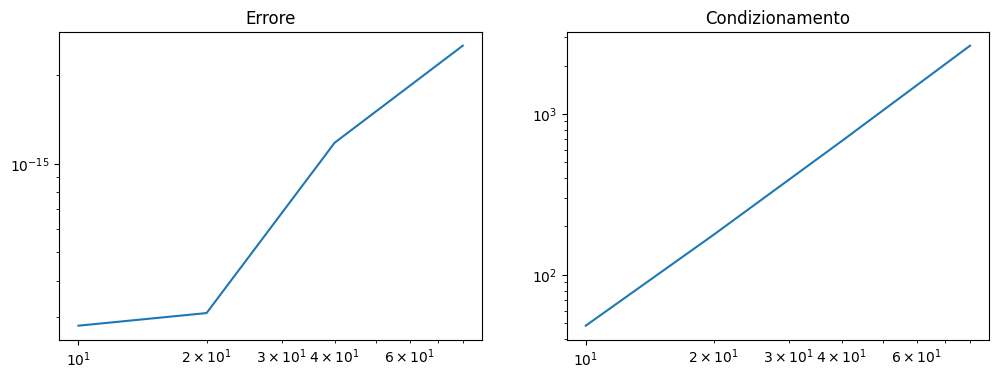

In [12]:
err = []
cond = []
N = np.array([10, 20, 40, 80])
for n in N:
    h = 1 / n
    R = np.ones(n)
    A = (
        2 / h * np.diag(R)
        - 1 / h * np.diag(R[0 : n - 1], -1)
        - 1 / h * np.diag(R[0 : n - 1], 1)
    )
    P, L, U = lu(A)
    x_ex = 2 * np.ones(n)
    b = A @ x_ex
    y = fwsub(L, P.T @ b)
    x = bksub(U, y)
    cond.append(np.linalg.cond(A))
    err.append(np.linalg.norm(x - x_ex) / np.linalg.norm(x_ex))

print(cond)
print(err)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.loglog(N, err)
plt.title("Errore")
plt.subplot(1, 2, 2)
plt.loglog(N, cond)
plt.title("Condizionamento")

Dal grafico ottenuto osserviamo che per matrici di dimensioni maggiori l'errore cresce (leggermente) questo si spiega con l'aumento del numero di condizionamento della matrice, che tuttavia non è molto alto in questo caso.

#### **(1d) (1 punto) [P+T]** 
Commentare l’andamento del condizionamento della matrice al variare di $n$ (o $h$). Cosa si osserva?

##### **Soluzione.** 


Sovrapponendo l'andamento di $n^2$ nel grafico in scala logaritmica osserviamo che il condizionamento cresce come $n^2$. E' un risultato che potevamo aspettarci notando che la matrice fornita è una matrice di *stiffness* in 1D, il cui condizionamento dipende dal passo di griglia $h$, in particolare $K(A)\propto h^{-2}$.       

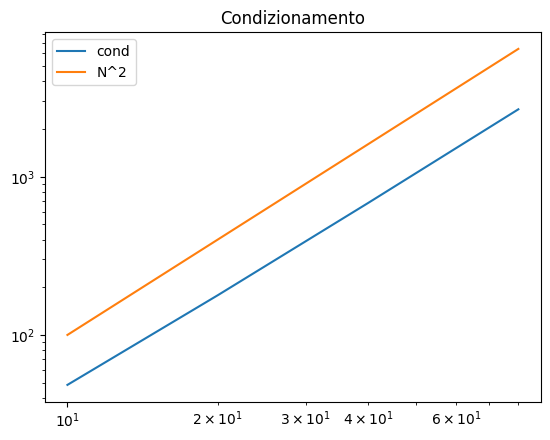

In [13]:
plt.loglog(N, cond, label="cond")
plt.loglog(N, N * N, label="N^2")
plt.legend()
plt.title("Condizionamento")
plt.show()